# Extract Bag-Of-Word (BOW) features from textual context

In [1]:
import gensim
import pandas as pd
import nltk as nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim import corpora

%matplotlib inline

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

rs = 123

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\flori\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\flori\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\flori\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\flori\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [2]:
# Build a set of example documents
course1 = "this is an introduction data science course which introduces data science to beginners"
course2 = "machine learning for beginners"
documents = [course1, course2]
# Tokenize words using nltk
tokenized_courses = [word_tokenize(course) for course in documents]
# Build a dictionary out of the tokens
tokens_dict = gensim.corpora.Dictionary(tokenized_courses)
# For each document, use the dictionary to build a BOW representation of that course description
courses_bow = [tokens_dict.doc2bow(course) for course in tokenized_courses]

In [3]:
# Enumerate through each course and its bag-of-words representation
for course_idx, course_bow in enumerate(courses_bow):
    # Print the index of the current course and a label
    print(f"Bag of words for course {course_idx}:")
    # For each token index, print its bow value (word count)
    for token_index, token_bow in course_bow:
        # Retrieve the token from the tokens dictionary based on its index
        token = tokens_dict.get(token_index)
        # Print the token and its bag-of-words value
        print(f"--Token: '{token}', Count:{token_bow}")

Bag of words for course 0:
--Token: 'an', Count:1
--Token: 'beginners', Count:1
--Token: 'course', Count:1
--Token: 'data', Count:2
--Token: 'introduces', Count:1
--Token: 'introduction', Count:1
--Token: 'is', Count:1
--Token: 'science', Count:2
--Token: 'this', Count:1
--Token: 'to', Count:1
--Token: 'which', Count:1
Bag of words for course 1:
--Token: 'beginners', Count:1
--Token: 'for', Count:1
--Token: 'learning', Count:1
--Token: 'machine', Count:1


## BOW Dimensionality Reduction

Since documents can be very large, resulting in a very large BOW vector, it is useful to select for words that have meaningful representational value. For example, very common words that don't really convey information like stop words or position and adjective words.

Below, the tokenised representation is filtered so the stopwords are removed.

In [4]:
stop_words = set(stopwords.words('english'))
processed_tokens = [w for w in tokenized_courses[0] if not w.lower() in stop_words]
processed_tokens

['introduction',
 'data',
 'science',
 'course',
 'introduces',
 'data',
 'science',
 'beginners']

Another option is to only keep the nouns. This can be achieved by first performing POS (Part Of Speech) tagging and filtering on the tags.

In [5]:
tags = nltk.pos_tag(tokenized_courses[0])
[word for word, tag in tags if tag in ["NN", "NNS"]]

['introduction', 'data', 'science', 'course', 'data', 'science', 'beginners']

## Building a BOW dataset for course textual context

In [6]:
course_content_df = pd.read_csv("./data/course_processed.csv")
course_content_df.head(5)

,COURSE_ID,TITLE,DESCRIPTION
0,ML0201EN,robots are coming build iot apps with watson ...,have fun with iot and learn along the way if ...
1,ML0122EN,accelerating deep learning with gpu,training complex deep learning models with lar...
2,GPXX0ZG0EN,consuming restful services using the reactive ...,learn how to use a reactive jax rs client to a...
3,RP0105EN,analyzing big data in r using apache spark,apache spark is a popular cluster computing fr...
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,learn how to containerize package and run a ...


In [7]:
course_content_df['course_texts'] = course_content_df[['TITLE', 'DESCRIPTION']].agg(' '.join, axis=1)
course_content_df = course_content_df.reset_index()
course_content_df['index'] = course_content_df.index
course_content_df.head(5)

,index,COURSE_ID,TITLE,DESCRIPTION,course_texts
0,0,ML0201EN,robots are coming build iot apps with watson ...,have fun with iot and learn along the way if ...,robots are coming build iot apps with watson ...
1,1,ML0122EN,accelerating deep learning with gpu,training complex deep learning models with lar...,accelerating deep learning with gpu training c...
2,2,GPXX0ZG0EN,consuming restful services using the reactive ...,learn how to use a reactive jax rs client to a...,consuming restful services using the reactive ...
3,3,RP0105EN,analyzing big data in r using apache spark,apache spark is a popular cluster computing fr...,analyzing big data in r using apache spark apa...
4,4,GPXX0Z2PEN,containerizing packaging and running a sprin...,learn how to containerize package and run a ...,containerizing packaging and running a sprin...


In [8]:
def tokenize_course(course, keep_only_nouns=True):
    # Get English stop words
    stop_words = set(stopwords.words('english'))
    # Tokenize the course text
    word_tokens = word_tokenize(course)
    # Remove English stop words and numbers
    word_tokens = [w for w in word_tokens if (not w.lower() in stop_words) and (not w.isnumeric())]
    # Only keep nouns 
    if keep_only_nouns:
        # Define a filter list of non-noun POS tags
        filter_list = ['WDT', 'WP', 'WRB', 'FW', 'IN', 'JJR', 'JJS', 'MD', 'PDT', 'POS', 'PRP', 'RB', 'RBR', 'RBS',
                       'RP']
        # Tag the word tokens with POS tags
        tags = nltk.pos_tag(word_tokens)
        # Filter out non-nouns based on POS tags
        word_tokens = [word for word, pos in tags if pos not in filter_list]

    return word_tokens

In [9]:
a_course = course_content_df.iloc[0]["course_texts"]
a_tokenized_course = tokenize_course(a_course)
a_tokenized_course[:10]

['robots',
 'coming',
 'build',
 'iot',
 'apps',
 'watson',
 'swift',
 'red',
 'fun',
 'iot']

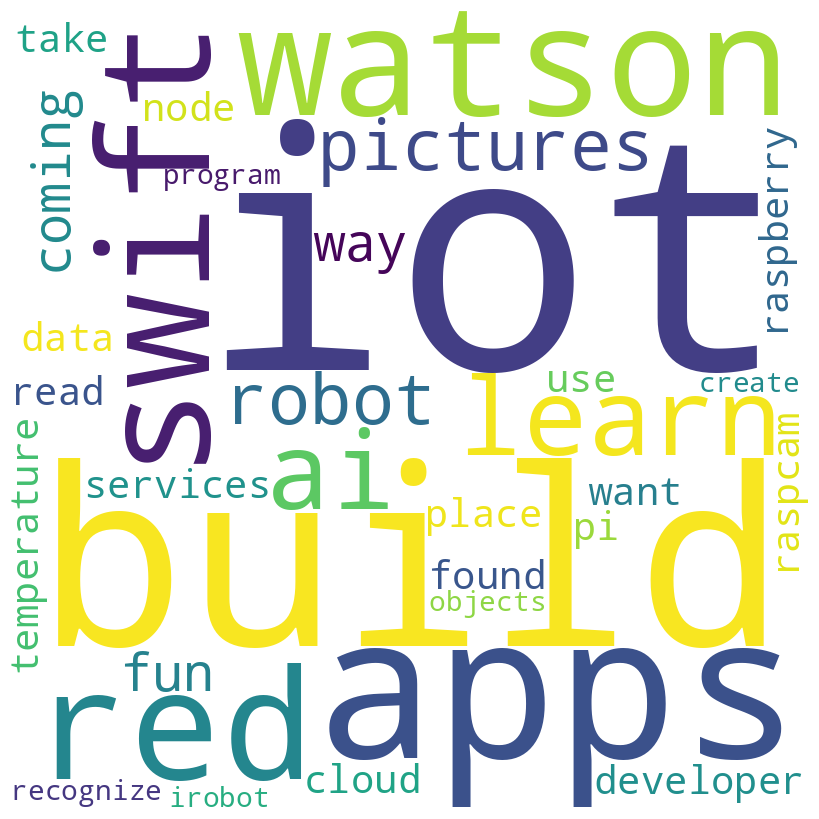

In [11]:
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# nltk.download('stopwords')
# text = "The acting in this movie was phenomenal! The plot kept me engaged throughout, and the characters were well-developed. However, the ending felt a bit rushed."
# words = text.split()
# stop_words = set(stopwords.words('english'))
# custom_stopwords = {'movie', 'plot', 'characters', 'ending'}  # Example custom stopwords
# stop_words.update(custom_stopwords)
# filtered_words = [word for word in words if word.lower() not in stop_words]
# filtered_text = ' '.join(filtered_words)

wordcloud = WordCloud(width=800, height=800,
                      background_color='white',
                      stopwords=stop_words,
                      min_font_size=10).generate(" ".join(a_tokenized_course))
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [ ]:
tokenized_courses = [tokenize_course(course, True) for course in course_content_df["course_texts"]]
tokens_dict = gensim.corpora.Dictionary(tokenized_courses)
courses_bow = [tokens_dict.doc2bow(course) for course in tokenized_courses]
courses_bow

[[(0, 2),
  (1, 2),
  (2, 2),
  (3, 1),
  (4, 1),
  (5, 1),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 4),
  (11, 1),
  (12, 2),
  (13, 1),
  (14, 1),
  (15, 1),
  (16, 2),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 1),
  (23, 2),
  (24, 1),
  (25, 1),
  (26, 1),
  (27, 2),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 2),
  (33, 1)],
 [(0, 2),
  (3, 2),
  (6, 1),
  (12, 1),
  (30, 4),
  (34, 1),
  (35, 5),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1),
  (40, 1),
  (41, 1),
  (42, 1),
  (43, 1),
  (44, 1),
  (45, 1),
  (46, 1),
  (47, 1),
  (48, 2),
  (49, 1),
  (50, 4),
  (51, 1),
  (52, 1),
  (53, 1),
  (54, 1),
  (55, 1),
  (56, 7),
  (57, 5),
  (58, 1),
  (59, 1),
  (60, 1),
  (61, 2),
  (62, 1),
  (63, 1),
  (64, 6),
  (65, 1),
  (66, 1),
  (67, 1),
  (68, 1),
  (69, 1),
  (70, 1),
  (71, 3),
  (72, 2),
  (73, 1),
  (74, 1),
  (75, 1),
  (76, 1),
  (77, 1),
  (78, 3),
  (79, 1),
  (80, 1),
  (81, 2),
  (82, 1),
  (83, 1),
  (84, 1),
  (85, 1),
  (86, 1),


In [ ]:
columns = ["doc_index", "doc_id", "token", "bow"]
df_list = []

for doc_index, course_bow in enumerate(courses_bow):

    doc_id = course_content_df.iloc[doc_index]["COURSE_ID"]

    for token_idx, token_bow in course_bow:
        
        token = tokens_dict[token_idx]
        df_list.append([doc_index, doc_id, token, token_bow])
    
bow_df = pd.DataFrame(df_list, columns=columns)


In [ ]:
bow_df.head(5)

,doc_index,doc_id,token,bow
0,0,ML0201EN,ai,2
1,0,ML0201EN,apps,2
2,0,ML0201EN,build,2
3,0,ML0201EN,cloud,1
4,0,ML0201EN,coming,1
